<a href="https://colab.research.google.com/github/peakodev/data_science/blob/main/home_11/Hw11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 11

В якості домашнього завдання вам пропонується створити рекурентну нейронну мережу за допомогою механізмів Keras, яка буде класифікувати рецензії із датасету imdb.

На відміну від прикладу в модулі 9 ми використаємо рекурентну нейронну мережу. Поекспериментуйте з будовою мережі - RNN, LSTM, двостороння та глибока.

Порівняйте результати та зробіть висновки.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
print("Розмір тренувального датасету:", len(x_train))
print("Розмір тестового датасету:", len(x_test))

Розмір тренувального датасету: 25000
Розмір тестового датасету: 25000


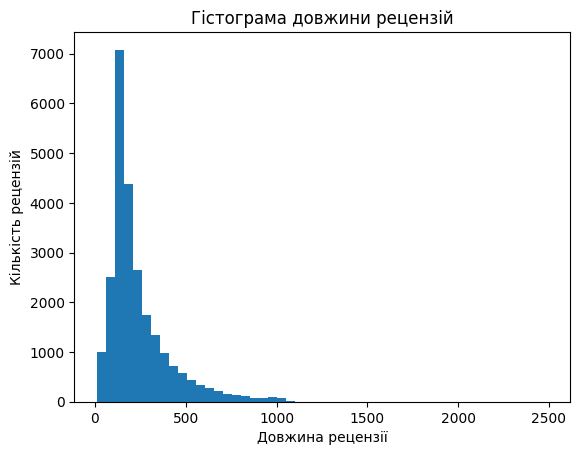

In [5]:
lengths = [len(review) for review in x_train]
plt.hist(lengths, bins=50)
plt.xlabel("Довжина рецензії")
plt.ylabel("Кількість рецензій")
plt.title("Гістограма довжини рецензій")
plt.show()

# usefull funtions

In [6]:
def plot_training_history(history):
    """
    Function to plot training and validation accuracy/loss on a single figure with subplots.

    Parameters:
    - history: The training history object returned by the Keras model after fitting.
    """
    # Extracting values from history
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # Create a figure with two subplots in one row
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plotting accuracy
    ax1.plot(epochs, acc, label='Точність на тренуванні')
    ax1.plot(epochs, val_acc, label='Точність на валідації')
    ax1.set_title('Точність тренування і валідації')
    ax1.set_xlabel('Епохи')
    ax1.set_ylabel('Точність')
    ax1.legend()
    ax1.grid(True)

    # Plotting loss
    ax2.plot(epochs, loss, label='Втрати на тренуванні')
    ax2.plot(epochs, val_loss, label='Втрати на валідації')
    ax2.set_title('Втрати тренування і валідації')
    ax2.set_xlabel('Епохи')
    ax2.set_ylabel('Втрати')
    ax2.legend()
    ax2.grid(True)

    # Display the plots
    plt.tight_layout()
    plt.show()

# download and prepare

In [7]:
max_features = 10000  # кількість слів, що розглядаються як особливості
maxlen = 500  # обмеження кількості слів в тексті
input_shape = (None, maxlen)

X = np.hstack([x_train, x_test])
y = np.hstack([y_train, y_test])

X_padded = pad_sequences(X, maxlen=maxlen)

x_train, x_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=22)

In [8]:
x_train.shape, x_test.shape

((40000, 500), (10000, 500))

# SimpleRNN

In [8]:
model_rnn = Sequential([
    Embedding(max_features, 64),
    SimpleRNN(128, activation="tanh"),
    Dense(1, activation="sigmoid")
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_rnn.build(input_shape)

model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 500, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 128)                 │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 664,833 (2.54 MB)

 Trainable params: 664,833 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_rnn = model_rnn.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 60s 58ms/step - accuracy: 0.5238 - loss: 0.6979 - val_accuracy: 0.5970 - val_loss: 0.6547
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 56s 56ms/step - accuracy: 0.6786 - loss: 0.6035 - val_accuracy: 0.6499 - val_loss: 0.6118
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.7457 - loss: 0.5231 - val_accuracy: 0.7284 - val_loss: 0.5430
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.7375 - loss: 0.5150 - val_accuracy: 0.6404 - val_loss: 0.6314
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.6947 - loss: 0.5669 - val_accuracy: 0.6378 - val_loss: 0.6373


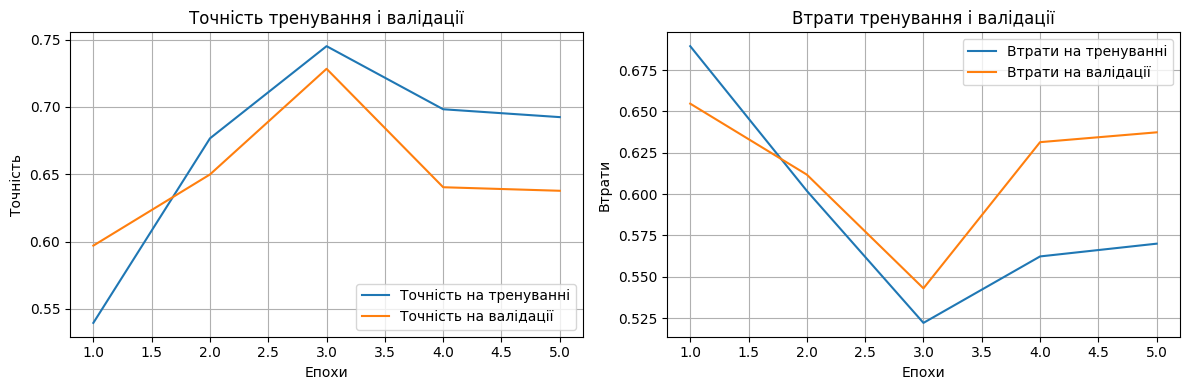

In [10]:
plot_training_history(history_rnn)

In [11]:
model_rnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6392 - loss: 0.6313


[0.6272159218788147, 0.6437000036239624]

# GRU

In [12]:
model_gru = Sequential([
    Embedding(max_features, 64),
    GRU(128, activation="tanh"),
    Dense(1, activation="sigmoid")
])

model_gru.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_gru.build(input_shape)

model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 500, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 128)                 │          74,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 714,625 (2.73 MB)

 Trainable params: 714,625 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_gru = model_gru.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.6702 - loss: 0.5793 - val_accuracy: 0.8106 - val_loss: 0.4825
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.8688 - loss: 0.3298 - val_accuracy: 0.8749 - val_loss: 0.3114
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9013 - loss: 0.2522 - val_accuracy: 0.9045 - val_loss: 0.2384
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9279 - loss: 0.1969 - val_accuracy: 0.9015 - val_loss: 0.2361
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9416 - loss: 0.1605 - val_accuracy: 0.9091 - val_loss: 0.2292


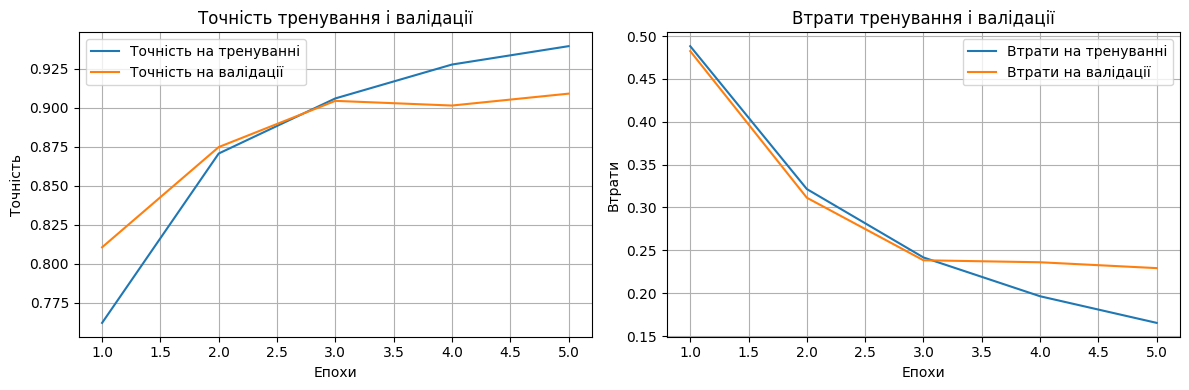

In [14]:
plot_training_history(history_gru)

In [16]:
model_gru.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9142 - loss: 0.2223


[0.2194574475288391, 0.9140999913215637]

# LSTM

In [17]:
model_lstm = Sequential([
    Embedding(max_features, 64),
    LSTM(128, activation="tanh"),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.build(input_shape)

model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 500, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 738,945 (2.82 MB)

 Trainable params: 738,945 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_lstm = model_lstm.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.8879 - loss: 0.2851 - val_accuracy: 0.8934 - val_loss: 0.2638
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9056 - loss: 0.2458 - val_accuracy: 0.8974 - val_loss: 0.2624
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 51s 35ms/step - accuracy: 0.9215 - loss: 0.2073 - val_accuracy: 0.8906 - val_loss: 0.3024
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9325 - loss: 0.1827 - val_accuracy: 0.8949 - val_loss: 0.2600
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9426 - loss: 0.1614 - val_accuracy: 0.8996 - val_loss: 0.2619


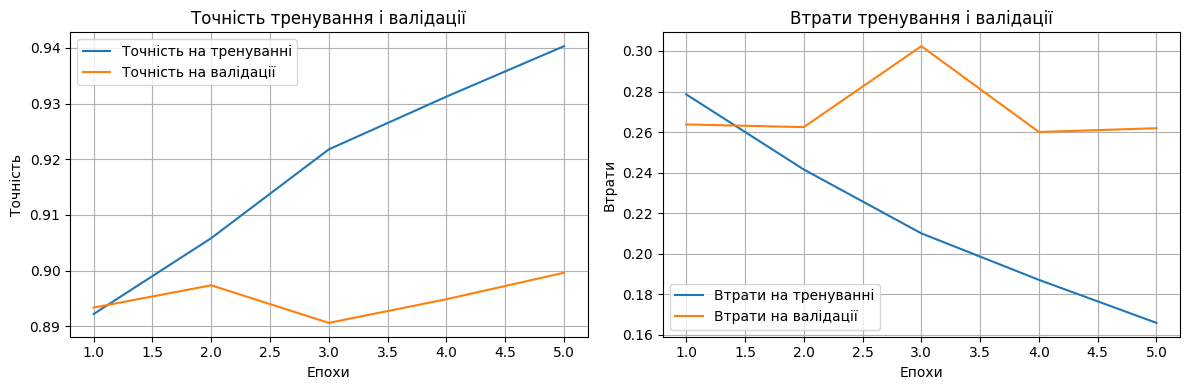

In [20]:
plot_training_history(history_lstm)

In [21]:
model_lstm.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8975 - loss: 0.2629


[0.25884711742401123, 0.9004999995231628]

# BRNN for LSTM

In [22]:
model_b_lstm = Sequential([
    Embedding(max_features, 64),
    Bidirectional(LSTM(128, activation="tanh")),
    Dense(1, activation="sigmoid")
])

model_b_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_b_lstm.build(input_shape)

model_b_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 500, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │         197,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 837,889 (3.20 MB)

 Trainable params: 837,889 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_b_lstm = model_b_lstm.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.7198 - loss: 0.5366 - val_accuracy: 0.8683 - val_loss: 0.3239
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.8725 - loss: 0.3107 - val_accuracy: 0.8065 - val_loss: 0.4210
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - accuracy: 0.8919 - loss: 0.2713 - val_accuracy: 0.8845 - val_loss: 0.2914
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9291 - loss: 0.1927 - val_accuracy: 0.8698 - val_loss: 0.3830
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.9424 - loss: 0.1559 - val_accuracy: 0.8813 - val_loss: 0.3338


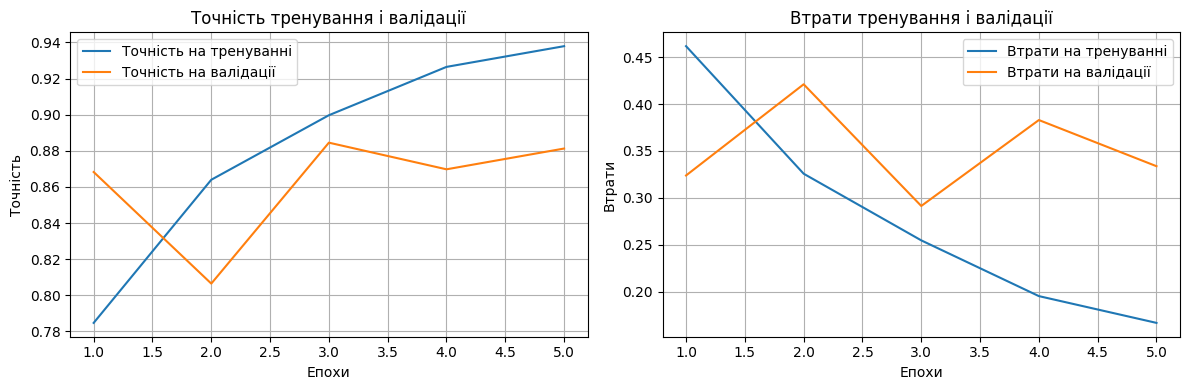

In [24]:
plot_training_history(history_b_lstm)

In [25]:
model_b_lstm.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8861 - loss: 0.3147


[0.31446975469589233, 0.8863999843597412]

# Deep RNN Bidirectional LSTM

In [27]:
model_deep = Sequential([
    Embedding(max_features, 64),
    LSTM(128, activation="tanh", return_sequences=True),
    LSTM(128, activation="tanh"),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_deep.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_deep.build(input_shape)

model_deep.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ (None, 500, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 500, 128)            │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 878,721 (3.35 MB)

 Trainable params: 878,721 (3.35 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history_deep = model_deep.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 44s 42ms/step - accuracy: 0.6193 - loss: 0.6432 - val_accuracy: 0.8550 - val_loss: 0.3567
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.8421 - loss: 0.3728 - val_accuracy: 0.8411 - val_loss: 0.3606
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.8824 - loss: 0.2867 - val_accuracy: 0.8892 - val_loss: 0.3033
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.9179 - loss: 0.2115 - val_accuracy: 0.8820 - val_loss: 0.2984
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9337 - loss: 0.1783 - val_accuracy: 0.8906 - val_loss: 0.2766


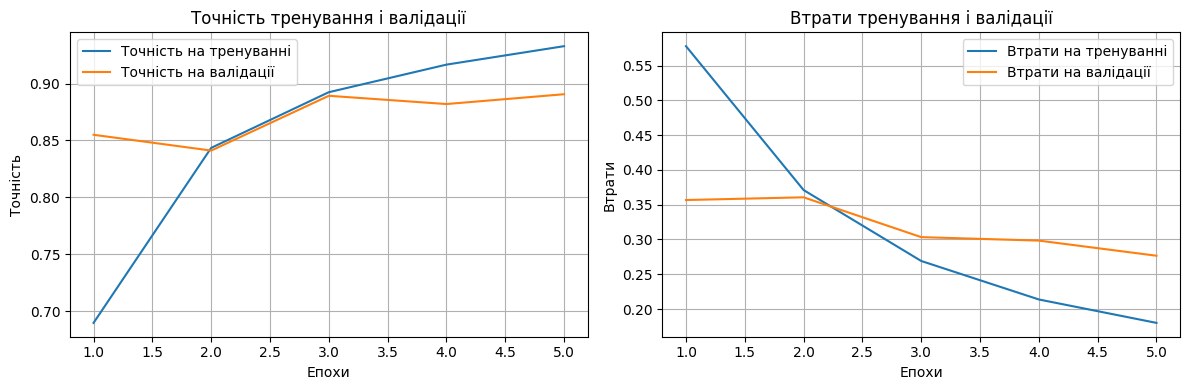

In [29]:
plot_training_history(history_deep)

In [30]:
model_deep.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8951 - loss: 0.2729


[0.26534026861190796, 0.8992999792098999]

# Deep RNN Bidirectional with GPU (relu)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)             │ (None, 500, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_12 (Bidirectional)     │ (None, 500, 128)            │          49,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_13 (Bidirectional)     │ (None, 64)                  │          31,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 737,665 (2.81 MB)

 Trainable params: 737,665 (2.81 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 395s 386ms/step - accuracy: 0.5557 - loss: 0.6762 - val_accuracy: 0.5220 - val_loss: 0.6754
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 474s 423ms/step - accuracy: 0.7759 - loss: 0.5712 - val_accuracy: 0.8920 - val_loss: 0.2599
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 442s 422ms/step - accuracy: 0.9008 - loss: 0.2525 - val_accuracy: 0.9072 - val_loss: 0.2300
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 446s 426ms/step - accuracy: 0.9234 - loss: 0.2024 - val_accuracy: 0.8622 - val_loss: 0.3326
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 436s 421ms/step - accuracy: 0.9366 - loss: 0.1744 - val_accuracy: 0.9112 - val_loss: 0.2232


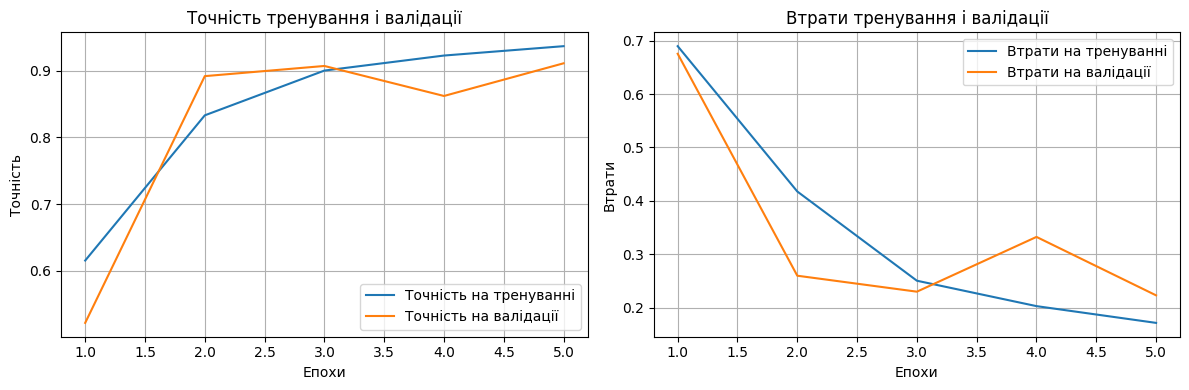

313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.9100 - loss: 0.2261


[0.21956908702850342, 0.9125000238418579]

In [36]:
model_deep2 = Sequential([
    Embedding(max_features, 64),
    Bidirectional(GRU(64, activation="relu", return_sequences=True)),
    Bidirectional(GRU(32, activation="relu")),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_deep2.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_deep2.build(input_shape)
model_deep2.summary()

history_deep2 = model_deep2.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

plot_training_history(history_deep2)
model_deep2.evaluate(x_test, y_test)

# Deep RNN Bidirectional GRU with drpouts and batch normalization

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 500, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_8 (Bidirectional)      │ (None, 500, 256)            │         198,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 500, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 500, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_9 (Bidirectional)      │ (None, 128)                 │         123,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,628,417 (6.21 MB)

 Trainable params: 1,627,521 (6.21 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 103ms/step - accuracy: 0.6873 - loss: 0.5993 - val_accuracy: 0.7029 - val_loss: 1.0855 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.9045 - loss: 0.2431 - val_accuracy: 0.8882 - val_loss: 0.2947 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.9281 - loss: 0.1874 - val_accuracy: 0.9082 - val_loss: 0.2483 - learning_rate: 0.0010
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.9446 - loss: 0.1509 - val_accuracy: 0.8600 - val_loss: 0.4198 - learning_rate: 0.0010
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 101ms/step - accuracy: 0.9563 - loss: 0.1209 - val_accuracy: 0.8827 - val_loss: 0.3364 - learning_rate: 0.0010
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9655 - loss: 0.0969 - val_accuracy: 0.9059 - val_loss: 0.2691 - learning_rate: 0.0010
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 102ms/step - accuracy: 0.979

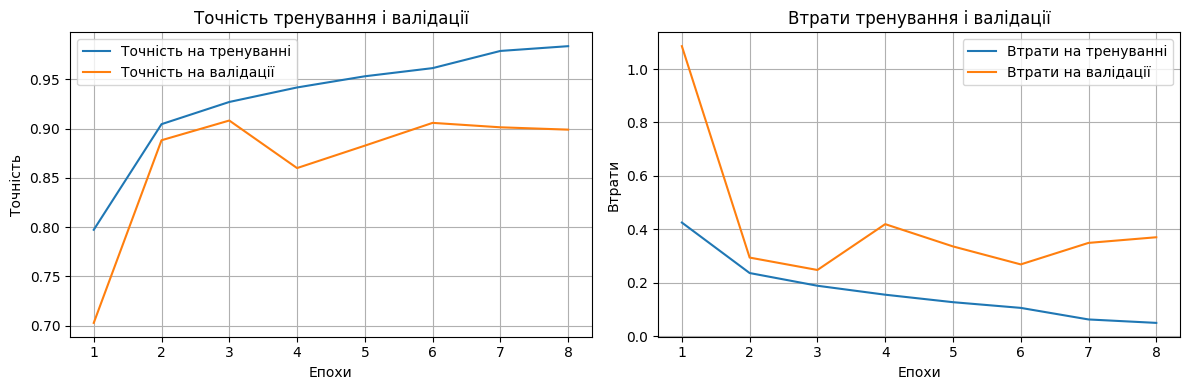

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9143 - loss: 0.2495


[0.24640516936779022, 0.9128999710083008]

In [13]:
model_deep3 = Sequential([
    Embedding(input_dim=max_features, output_dim=128),
    Bidirectional(GRU(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.3),
    Bidirectional(GRU(64)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_deep3.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_deep3.build(input_shape)
model_deep3.summary()

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-5)
]

history_deep3 = model_deep3.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks
)

plot_training_history(history_deep3)
model_deep3.evaluate(x_test, y_test)